# Notebook to Analyzed Measured data

Python Notebook to analyzed the cycle to cycle measured RRAM device during the lab experience.
Only the currents measured at Vread = 0.2 V is extracted for each state.
Normal distributions are extracted from the obtained data in order to include the device behaviour in the CNN evaluation with CrossSim.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
arr = np.array([10, 50, 20, 40, 30])

# Get indices of the top 3 values
top3_indices = np.argpartition(arr, -3)[-3:]

# If you want them sorted by actual value (descending order):
top3_sorted_indices = top3_indices[np.argsort(arr[top3_indices])[::-1]]

print("Indices of top 3 values:", top3_sorted_indices)
print("Top 3 values:", arr[top3_sorted_indices])

Indices of top 3 values: [1 3 4]
Top 3 values: [50 40 30]


In [7]:

# --- Set the directory containing the Excel files ---
# folder_path = './measurements/fac-simil'  # TODO: Change this to your actual folder path
folder_path = './measurements/day-before'  # TODO: Change this to your actual folder path

# --- File mapping: filename to variable name ---
file_map = {
    "set_1V6.xlsx": "LRS3_cycles_Vread",
    "set_1V4.xlsx": "LRS2_cycles_Vread",
    "set_1V2.xlsx": "LRS1_cycles_Vread",
    "reset_1V6.xlsx": "HRS_cycles_Vread",
    "reset_1V4.xlsx": "HRS_cycles_Vread",
    "reset_1V2.xlsx": "HRS_cycles_Vread"
}


# --- Dictionary to store the extracted data ---
data_dict = {
    "LRS3_cycles_Vread": [],
    "LRS2_cycles_Vread": [],
    "LRS1_cycles_Vread": [],
    "HRS_cycles_Vread": []
}

In [8]:

reading_voltage = 0.2  # Volts

# --- Loop through each file and extract the required data ---
for filename, var_name in file_map.items():
    file_path = os.path.join(folder_path, filename)
    
    # Read the Excel file
    df = pd.read_excel(file_path)
    
    # Extract the row index 281 (283 in excel), excluding first column and last 3 columns
    # NOTE: It is the columns at 0.2 V after the set/rest opreation is concluded
    current_values = df.iloc[281, 1:-3].values  # 0-indexed: row 281, skip first col, exclude last 3
    conductance_values = current_values / reading_voltage  # Convert current to conductance (S)
    data_dict[var_name].extend(conductance_values)  # Add data to the corresponding list



--- Fit Results ---
LRS3: Median = 474.010 uS (2109.659 Ohm), Sigma = 43.410 uS
LRS2: Median = 339.523 uS (2945.310 Ohm), Sigma = 5.293 uS
LRS1: Median = 230.818 uS (4332.411 Ohm), Sigma = 11.622 uS
HRS: Median = 80.257 uS (12460.001 Ohm), Sigma = 215.114 uS


Average Sigma: 68.860 uS



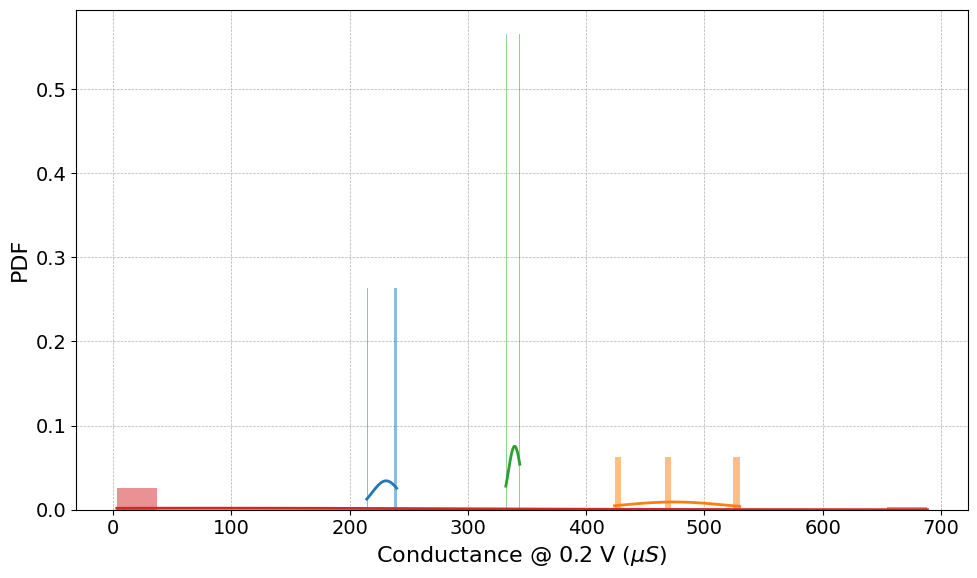

In [9]:
# --- Fit normal distributions and store mean/sigma ---
fit_results = {}

# Define colors for each group
colors = {
    "LRS3_cycles_Vread": "tab:orange",
    "LRS2_cycles_Vread": "tab:green",
    "LRS1_cycles_Vread": "tab:blue",
    "HRS_cycles_Vread": "tab:red"
}

labels_to_plot = {
    "LRS3_cycles_Vread": "LRS3",
    "LRS2_cycles_Vread": "LRS2",
    "LRS1_cycles_Vread": "LRS1",
    "HRS_cycles_Vread": "HRS"
}

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})


fig, ax = plt.subplots(figsize=(10, 6))

# Loop through datasets and plot histograms with normal fit
for label, values in data_dict.items():
    values = np.array(values, dtype=np.float64) * 1e6  # Convert to µS

    # Fit a normal distribution
    mu, sigma = norm.fit(values)
    fit_results[label] = (mu, sigma)

    # Plot histogram
    color = colors[label]
    count, bins, _ = ax.hist(values, bins=20, density=True, alpha=0.5,
                         label=f'{labels_to_plot[label]} (μ={mu:.2f}uS, σ={sigma:.2f}uS)',
                         color=color)

    # Plot fitted normal distribution
    x = np.linspace(bins[0], bins[-1], 100)
    pdf = norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color=color, linewidth=2)

# Format the plot using ax
ax.set_xlabel(r"Conductance @ $0.2$ V ($\mu S$)")
ax.set_ylabel("PDF")

ax.set_axisbelow(True)
ax.grid(True, which="both", ls="--", lw=0.5)
# ax.legend(loc='upper right', bbox_to_anchor=(0.95,0.95), framealpha=1.0)

# --- Print the fit results ---
sigma_list = []
print("\n--- Fit Results ---")
for label, (mu, sigma) in fit_results.items():
    print(f"{labels_to_plot[label]}: Median = {mu:.3f} uS ({1/mu*1e6:.3f} Ohm), Sigma = {sigma:.3f} uS")
    sigma_list.append(sigma)

average = np.mean(sigma_list)
print(f"\n\nAverage Sigma: {average:.3f} uS\n")


# Tight layout and show
fig.tight_layout()

# plt.savefig(f"Extracted_Distribution_fac-simil.png")
plt.show()